# Real-Time Foreground Segmentation and Selective Blur on the GPU

**CSC14116 — Applied Parallel Programming** · Huỳnh Lê Hải Dương (22127081) · Nguyễn Đức Tín (22127415)
Repo: `github.com/Sn-cpp/Adaptive-Gaussian-Mixture-Model` · **Recorded performance → Tesla T4** · live cells use the current runtime

**1** Introduction · **2** Methods · **3** Evaluation · **4** Discussion · **5** Conclusion
*Charts use committed records (`RESULTS-T4.md`, `benchmarks/records/`) or recompute live. Cells marked ⏱ take minutes, so their last recorded result is shown beside them.*

In [1]:
import matplotlib.pyplot as plt, numpy as np

# Palette validated for CVD safety (dataviz six-checks): identity is fixed —
# v0 blue, v1 amber, v2 red (red = the submitted version, everywhere).
C = {"v0": "#2a78d6", "v1": "#eda100", "v2": "#c0392b",
     "ink": "#1a1a19", "muted": "#8a8a85", "good": "#008300"}
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10, "axes.grid": True, "grid.alpha": .25,
    "grid.linestyle": "--", "axes.axisbelow": True, "axes.spines.top": False,
    "axes.spines.right": False, "figure.facecolor": "white",
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"]})

def take(msg):
    """One bold takeaway line under a figure — the sentence to say out loud."""
    from IPython.display import display, Markdown
    display(Markdown(f"**▸ {msg}**"))

In [2]:
import os, subprocess, sys

def repo_root():
    for c in (os.getcwd(), "/content/project", os.path.join(os.getcwd(), "project")):
        if os.path.isdir(os.path.join(c, ".git")) and os.path.exists(os.path.join(c, "gmm_mask")):
            return c
    return None

root = repo_root()
if root is None:
    dest = "/content/project" if os.path.isdir("/content") else "project"
    subprocess.run(["git", "clone", "-q", "--depth", "1",
        "https://github.com/Sn-cpp/Adaptive-Gaussian-Mixture-Model.git", dest], check=True)
    root = dest
os.chdir(root); sys.path.insert(0, root)
subprocess.run([sys.executable, "-m", "pip", "-q", "install", "numba<0.62"], capture_output=True)

import cv2, numba, platform
from numba import cuda
HAS_GPU = cuda.is_available()
base = subprocess.run(["git","rev-parse","--short","HEAD"], capture_output=True, text=True).stdout.strip()
impl_clean = subprocess.run(["git","diff","--quiet","HEAD","--",".",":(exclude)notebook.ipynb"]).returncode == 0
print(f"base commit {base} | implementation files clean: {impl_clean}")
print(f"python {platform.python_version()} | cv2 {cv2.__version__} | numba {numba.__version__} | GPU: {HAS_GPU}")

base commit 0d59b74 | implementation files clean: True
python 3.12.13 | cv2 5.0.0 | numba 0.61.2 | GPU: False


In [3]:
import glob, socket, urllib.request, zipfile, hashlib
socket.setdefaulttimeout(30)
HIGHWAY = os.environ.get("HIGHWAY_DIR", "highway")

def usable(d):
    return os.path.isdir(os.path.join(d, "input")) and os.path.isdir(os.path.join(d, "groundtruth"))

if not usable(HIGHWAY):
    local = glob.glob("highway.zip") + glob.glob("/content/highway.zip")
    if not local:
        # original CDnet hosts are offline; this is the team's mirror (CDnet citation on the card)
        url = ("https://huggingface.co/datasets/haiduonghuynhle/"
               "changedetection-2012-highway/resolve/main/highway.zip")
        try:
            urllib.request.urlretrieve(url, "highway.zip"); local = ["highway.zip"]
        except Exception as e:
            print("download failed:", e)
    if local:
        with zipfile.ZipFile(local[0]) as z: z.extractall(".")

HAS_DATA = usable(HIGHWAY)
os.environ["HIGHWAY_DIR"] = HIGHWAY
print("CDnet highway present:", HAS_DATA)

import numpy as np
def load_sequence(n, size=(320, 240)):
    """Frames for the figures: CDnet if present, else labelled synthetic."""
    if HAS_DATA:
        out = [cv2.imread(f"{HIGHWAY}/input/in{i:06d}.jpg") for i in range(1, n + 1)]
        out = [f for f in out if f is not None]
        if out: return out, "CDnet highway"
    import bench_post
    return bench_post.make_frames(n, size), "synthetic (illustrative only)"

CDnet highway present: True


## 1 · Introduction

**Input:** fixed-camera traffic video — a stream of BGR frames (320×240 CDnet up to 1920×1080 real footage).
**Output, per frame:** (a) a binary foreground mask — 255 on moving vehicles, 0 elsewhere; (b) a composite frame — vehicles sharp, everything else Gaussian-blurred.
**Goal:** produce both in real time (≥30 FPS at 1080p), with mask quality scored against hand-labelled ground truth: **CDnet `baseline/highway`**, frames 470–1700, don't-care pixels excluded.

*Dataset scope: the CDnet hosts are offline, so we use our HuggingFace mirror; its sha256 is recorded in `benchmarks/records/eval_highway_full.txt`. No labelled 1080p dataset exists, so 1080p is throughput-only.*

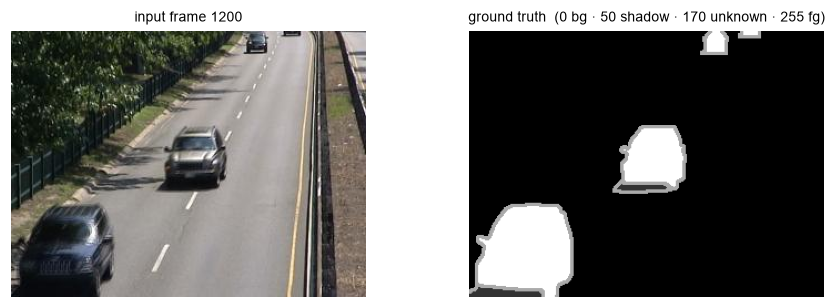

**▸ Every quality number in this notebook is scored against these hand-made labels.**

In [4]:
if HAS_DATA:
    i = 1200
    frame = cv2.imread(f"{HIGHWAY}/input/in{i:06d}.jpg")
    gt    = cv2.imread(f"{HIGHWAY}/groundtruth/gt{i:06d}.png", 0)
    fig, ax = plt.subplots(1, 2, figsize=(8.5, 2.9))
    ax[0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)); ax[0].set_title(f"input frame {i}", fontsize=9)
    ax[1].imshow(gt, cmap="gray"); ax[1].set_title("ground truth  (0 bg · 50 shadow · 170 unknown · 255 fg)", fontsize=9)
    for a in ax: a.axis("off")
    plt.tight_layout(); plt.show()
    take("Every quality number in this notebook is scored against these hand-made labels.")

### 1.1 · Why a GPU

| | |
|---:|---|
| **2 073 600** | pixels per 1080p frame |
| **25 values/px → 207 MB** | model state kept on the GPU and read every frame (5 Gaussians × 5 numbers, 4 bytes each) |
| **3 035 ms/frame** | sequential Python at 480p (`benchmarks/records/`) |
| **30 FPS** | the real-time target |

Each pixel updates independently, so one frame maps to 2 million threads (small units of parallel work). Only one stage resists this approach; §2.5 explains why.

## 2 · Methods

One algorithm — MOG2 (Zivkovic 2004), a per-pixel mixture of Gaussians — and five implementations: Sequential Python, Numba CPU, and CUDA v0, v1, v2. The CPU pair is the readable specification and the honest compiled baseline; the CUDA trio is the optimization ladder below. CUDA — the platform for running many small jobs in parallel on a GPU.

### The algorithm in 14 lines — `mog2_step`, run once per pixel per frame

```text
for each pixel (y, x), one thread:
    bg_weight = 0;  matched = False
    for each Gaussian mode k = 0..K-1, kept sorted by weight:
        dist² = ‖pixel − mean_k‖²                      # YCrCb, float32
        if dist² < Tb·var_k:                           # loose fit → background evidence
            bg_weight += w_k                           # ← the branch behind the 2-pixel story (§3.1)
            if weight counted so far < TB: pixel is background
        if not matched and dist² < Tg·var_k:           # tight fit → adapt this mode
            matched = True
            w_k += α;  mean_k, var_k step toward the pixel (rate α/w_k);  re-sort k up
        w_k = (1−α)·w_k − α·CT                         # decay; drop the mode if it falls below the floor
    normalise weights;  bg_prob[y,x] = bg_weight
    if not matched: replace the weakest mode with (pixel, var_init, weight α)
```

| Parameter | Value (`settings.py`, = OpenCV defaults) | Meaning |
|---|---|---|
| K | 5 | Gaussian modes per pixel |
| α | 1/250 after warm-up (`history` 250) | learning rate — how fast the background adapts |
| **Tb** | 16 | loose fit, in units of variance: "close enough to count as background" |
| **Tg** | 9 | tight fit: "close enough to *update* this mode" (Tb > Tg) |
| **TB** | 0.9 | cumulative weight that constitutes the background model |
| CT | 0.05 | prune rate — modes seen too rarely are deleted |
| var_init / clamp | 15, [4, 75] | variance of a fresh mode, and its bounds |

The shipping mask then thresholds confidence: foreground where `bg_prob < 0.5` (§2.6).

### 2.2 · The optimization ladder

| Version | Ladder level | What changed |
|---|---|---|
| **v0** | L1 naive port | model kernel (GPU function run in parallel), one thread per pixel. Correct — but every other stage still runs on the host. |
| **v1** | L2 memory | frame upload cut from 12 to 3 B/px; integer YCrCb conversion, threshold, median, blur and composite all moved onto the device — the mask stops round-tripping over the bus |
| **v2** | L2 + L3 | threshold fused into the model kernel's ending (one launch and one full-frame pass saved); median and blur rebuilt on shared-memory tiles (fast on-chip data blocks) |

State is planar (`means[k][c][y][x]`) in **every** version, so neighbouring threads read neighbouring bytes (coalesced) from v0 on — v1's gain is moving data less, not a new layout. Fusion stops exactly where correctness would break: the median needs 25 thresholded neighbours, and recomputing them inside the model kernel would apply the state update twice. v1 also implements adaptive alpha and neighbor propagation — off by default, unscored, not in the shipping path.

### What each version buys — recorded, per frame

| Version | Per frame (1080p real footage unless noted) | FPS | Source |
|---|---|---|---|
| Sequential Python | 3 034.62 ms at 480p (L0 baseline) | 0.3 | `RESULTS-T4.md` §3 |
| Numba CPU | 145.79 ms | 7 | `benchmarks/records/t4_final_run.txt` |
| CUDA v0 | 53.64 ms | 19 | same record |
| CUDA v1 | 13.41 ms | 75 | same record |
| CUDA v2 | 11.07 ms | 90 | same record |

In [5]:
# Recorded on a Colab Tesla T4 (RESULTS-T4.md, benchmarks/records/). Quoted, because charts need a
# GPU-measured input and this notebook must render on a CPU-only machine too.
SIZES = ["480p", "720p", "1080p"]
T4 = {"v0": {"ms": [10.22, 20.82, 55.03], "fps": [97.9, 48.0, 18.2]},
      "v1": {"ms": [3.74, 6.98, 13.75],   "fps": [267.3, 143.3, 72.8]},
      "v2": {"ms": [3.26, 6.02, 11.26],   "fps": [307.1, 166.2, 88.8]}}
BUS = {"v0": [6.97, 15.67, 35.25], "gpu": [3.28, 7.37, 16.59]}
PERSTAGE = {  # ms/frame per stage, [480p, 720p, 1080p]
    "v0": {"mask production": [6.278, 12.302, 35.924], "host fill_holes": [0.965, 2.155, 4.622],
           "blur + composite": [3.385, 6.333, 14.383]},
    "v1": {"mask production": [1.175, 1.940, 3.651],   "host fill_holes": [0.877, 1.938, 4.441],
           "blur + composite": [1.616, 3.083, 6.057]},
    "v2": {"mask production": [1.149, 1.984, 3.510],   "host fill_holes": [0.882, 1.972, 4.719],
           "blur + composite": [1.108, 2.044, 3.665]}}
# Measured 2026-08-21 on a Colab T4 at commit f6c0bfc, real 1080p traffic clip
# (Pexels 4791721), 152 timed frames, decode excluded — record:
# benchmarks/records/t4_final_run.txt
REALFOOTAGE_T4 = {
    "tiers": ["240p", "480p", "720p", "1080p"],
    "numba": {"ms": [5.47, 25.95, 64.17, 145.79], "fps": [183, 39, 16, 7]},
    "v0":    {"ms": [2.99, 11.33, 23.05, 53.64],  "fps": [334, 88, 43, 19]},
    "v1":    {"ms": [1.92, 4.85, 6.70, 13.41],    "fps": [520, 206, 149, 75]},
    "v2":    {"ms": [1.41, 4.29, 5.70, 11.07],    "fps": [708, 233, 175, 90]},
}

### 2.3 · Memory: cutting bus traffic in half

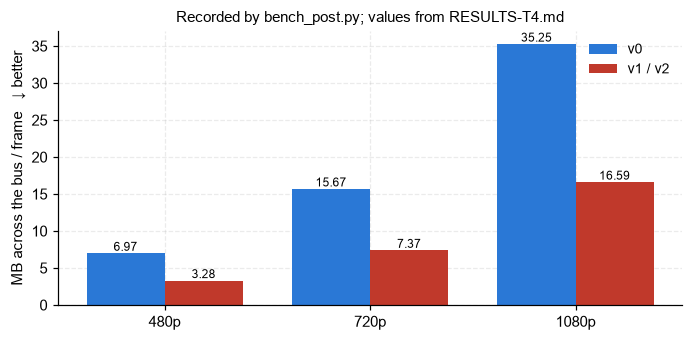

**▸ At 1080p: 35.25 → 16.59 MB per frame. The frame goes up as 3 bytes a pixel instead of 12, and the confidence map stops coming back.**

In [6]:
x = np.arange(3)
fig, ax = plt.subplots(figsize=(6.4, 3.2))
b1 = ax.bar(x - .19, BUS["v0"], .38, label="v0", color=C["v0"])
b2 = ax.bar(x + .19, BUS["gpu"], .38, label="v1 / v2", color=C["v2"])
ax.bar_label(b1, fmt="%.2f", fontsize=8); ax.bar_label(b2, fmt="%.2f", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(SIZES); ax.set_ylabel("MB across the bus / frame   ↓ better")
ax.legend(frameon=False, fontsize=9)
ax.set_title("Recorded by bench_post.py; values from RESULTS-T4.md", fontsize=9.5)
plt.tight_layout(); plt.show()
take(f"At 1080p: {BUS['v0'][2]} → {BUS['gpu'][2]} MB per frame. The frame goes up as "
     f"3 bytes a pixel instead of 12, and the confidence map stops coming back.")

### 2.4 · The blur kernel: an unexpected result

We planned a separable Gaussian blur, then found that **`cv2.GaussianBlur` on `uint8` is not a floating-point convolution.** It scales the kernel to $1/256$, uses integer arithmetic, and applies cumulative rather than per-tap quantisation.

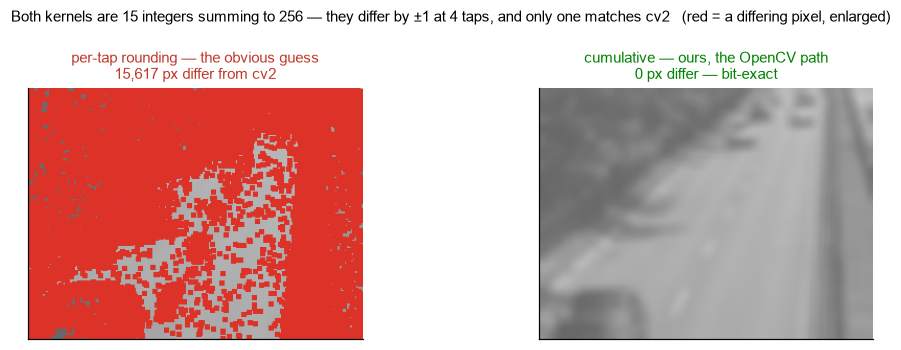

**▸ Our fixed-point chain: 0 of 230,400 channel values differ from cv2. A *correct* float64 Gaussian differs on 14.8% — that gap is OpenCV's, and matching it means inheriting it.**

In [7]:
from gmm_mask.gpu.blur_kernels import gaussian_kernel_q8, blur_reference
from settings import BLUR_KSIZE, BLUR_SIGMA

k   = cv2.getGaussianKernel(BLUR_KSIZE, BLUR_SIGMA).ravel()
KQ  = gaussian_kernel_q8()                       # cumulative — what OpenCV does
per = np.rint(k * 256).astype(KQ.dtype)          # per-tap — the obvious guess

# blur ONE real frame both ways and compare each result with cv2, pixel by pixel
img = (cv2.imread(f"{HIGHWAY}/input/in000700.jpg") if HAS_DATA
       else np.random.default_rng(0).integers(0, 256, (240, 320, 3), np.uint8))
ref = cv2.GaussianBlur(img, (BLUR_KSIZE, BLUR_KSIZE), BLUR_SIGMA)
show = cv2.cvtColor(ref, cv2.COLOR_BGR2GRAY)
DIL = np.ones((5, 5), np.uint8)                  # differences enlarged for visibility

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2))
for ax, kern, name, col in [(axes[0], per, "per-tap rounding — the obvious guess", C["v2"]),
                            (axes[1], KQ,  "cumulative — ours, the OpenCV path",  C["good"])]:
    d = (blur_reference(img, kern) != ref).any(axis=2)
    n = int(d.sum())
    overlay = np.stack([show]*3, -1) // 2 + 96
    overlay[cv2.dilate(d.astype(np.uint8), DIL) > 0] = [220, 50, 40]
    ax.imshow(overlay); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{name}\n{n:,} px differ from cv2" if n else
                 f"{name}\n0 px differ — bit-exact", fontsize=9.5, color=col)
fig.suptitle("Both kernels are 15 integers summing to 256 — they differ by ±1 at 4 taps, "
             "and only one matches cv2   (red = a differing pixel, enlarged)", fontsize=9.5)
plt.tight_layout(); plt.show()

rng = np.random.default_rng(0); bad = tot = 0
for s in range(4):
    t = rng.integers(0, 256, (120, 160, 3), dtype=np.uint8)
    d = blur_reference(t, KQ) != cv2.GaussianBlur(t, (BLUR_KSIZE, BLUR_KSIZE), BLUR_SIGMA)
    bad += int(d.sum()); tot += d.size
ideal = np.floor(cv2.sepFilter2D(t.astype(np.float64), cv2.CV_64F, k, k,
                 borderType=cv2.BORDER_REFLECT_101) + .5).astype(np.uint8)
gap = (np.abs(ideal.astype(int) - blur_reference(t, KQ).astype(int)) != 0).mean()
take(f"Our fixed-point chain: {bad} of {tot:,} channel values differ from cv2. "
     f"A *correct* float64 Gaussian differs on {gap:.1%} — that gap is OpenCV's, and matching it means inheriting it.")

The full integer path gives the same result across rounding modes and compiler flags: **zero different pixels on all four OpenCV builds we tested, on ARM and x86**. The float32 (single-precision floating-point) model kernel cannot make that guarantee.

### 2.5 · The stage we kept on the CPU

OpenCV's `fill_holes` uses a scan-line flood fill (a row-by-row region fill), which is sequential. A parallel alternative exists: repeatedly dilate one pixel inward from the border. The practical question is whether its cost is worthwhile.

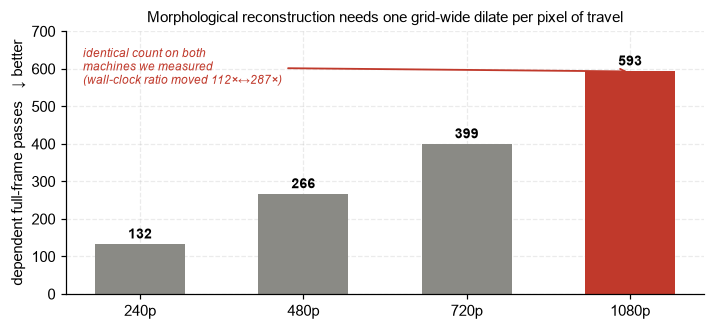

**▸ A CUDA dilate a hundred times faster still needs all 593, in sequence. Knowing which stage NOT to move is a result.**

In [8]:
PASSES = {"240p": 132, "480p": 266, "720p": 399, "1080p": 593}
fig, ax = plt.subplots(figsize=(6.6, 3.1))
cols = [C["muted"]]*3 + [C["v2"]]
b = ax.bar(list(PASSES), list(PASSES.values()), .55, color=cols)
ax.bar_label(b, fmt="%d", fontsize=9, fontweight="bold", padding=2)
ax.set_ylabel("dependent full-frame passes   ↓ better"); ax.set_ylim(0, 700)
ax.set_title("Morphological reconstruction needs one grid-wide dilate per pixel of travel",
             fontsize=10)
ax.annotate("identical count on both\nmachines we measured\n(wall-clock ratio moved 112×↔287×)",
            xy=(3, 593), xytext=(-0.35, 560), fontsize=8, style="italic", color=C["v2"],
            arrowprops=dict(arrowstyle="->", color=C["v2"], lw=1.2))
plt.tight_layout(); plt.show()
take("A CUDA dilate a hundred times faster still needs all 593, in sequence. "
     "Knowing which stage NOT to move is a result.")

*Each size uses one seeded synthetic mask and CPU timings. We did not build a CUDA reconstruction. The result shows that this formulation needs hundreds of dependent passes; it does not claim that every parallel flood fill is too slow.*

This is the course's **Partial GPU Principle**: *"identifying the one or two operations that dominate runtime and accelerating those — not rewriting an entire application."*

### 2.6 · Choosing the post chain by measurement

We tested thirteen candidate chains in two colour spaces over the full 470–1700 window.
The chart reads the committed results from `benchmarks/records/eval_highway_full.txt`.

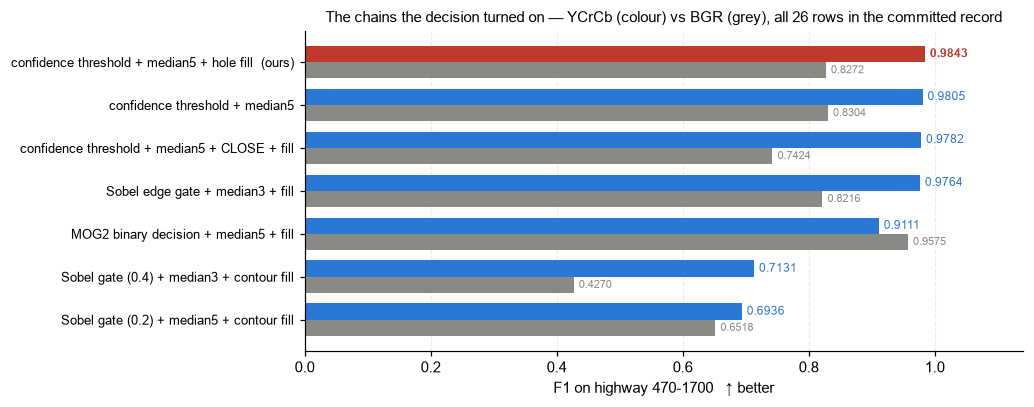

**▸ Colour space beats every post-processing choice: the shipping chain scores 0.827 on BGR and 0.9843 on YCrCb.**

In [9]:
import re

def parse_record(path="benchmarks/records/eval_highway_full.txt"):
    """(colorspace, chain, F1, IoU, P, R) rows straight from the committed run."""
    rows, cs = [], None
    for line in open(path):
        m = re.match(r"highway 470-1700 .*model input = (\w+)", line.strip())
        if m: cs = m.group(1); continue
        m = re.match(r"\s{2}(\S.*?)\s{2,}([\d.]{6})\s+([\d.]{6})\s+([\d.]{6})\s+([\d.]{6})\s+(\d+)\s+([\d.]+)$", line.rstrip())
        if m and cs:
            rows.append((cs, m.group(1).strip(), *map(float, m.groups()[1:5])))
    return rows

rows = parse_record()
SHIP = "bg_prob + median5 + fill"
# the chains the decision actually turned on; all 26 rows stay in the committed record
KEY = [SHIP, "bg_prob + median5", "mask + median5 + fill",
       "sobel gate + median3 + fill", "bg_prob + median5 + close15 + fill",
       "Tin dd40d92: gate.4 + med3 + contour",
       "Tin 1fe1c5e: gate.2 + med5 + contour+fill"]
f1 = {(r[0], r[1]): r[2] for r in rows}
KEY = sorted(KEY, key=lambda c: f1[("ycrcb", c)])
DISPLAY = {  # method descriptions for the axis; record keys stay as committed
    "bg_prob + median5 + fill":            "confidence threshold + median5 + hole fill  (ours)",
    "bg_prob + median5":                   "confidence threshold + median5",
    "bg_prob + median5 + close15 + fill":  "confidence threshold + median5 + CLOSE + fill",
    "mask + median5 + fill":               "MOG2 binary decision + median5 + fill",
    "sobel gate + median3 + fill":         "Sobel edge gate + median3 + fill",
    "Tin dd40d92: gate.4 + med3 + contour":      "Sobel gate (0.4) + median3 + contour fill",
    "Tin 1fe1c5e: gate.2 + med5 + contour+fill": "Sobel gate (0.2) + median5 + contour fill",
}

fig, ax = plt.subplots(figsize=(9.5, 3.8))
y = np.arange(len(KEY))
for c, yy in zip(KEY, y):
    col = C["v2"] if c == SHIP else C["v0"]
    ax.barh(yy + .19, f1[("ycrcb", c)], .38, color=col)
    ax.barh(yy - .19, f1[("bgr", c)], .38, color=C["muted"])
    ax.text(f1[("ycrcb", c)] + .008, yy + .19, f'{f1[("ycrcb", c)]:.4f}', va="center",
            fontsize=8, fontweight="bold" if c == SHIP else "normal", color=col)
    ax.text(f1[("bgr", c)] + .008, yy - .19, f'{f1[("bgr", c)]:.4f}', va="center",
            fontsize=7.5, color=C["muted"])
ax.set_yticks(y); ax.set_yticklabels([DISPLAY.get(c, c) for c in KEY], fontsize=8.5)
ax.set_xlim(0, 1.14); ax.set_xlabel("F1 on highway 470-1700   ↑ better")
ax.set_title("The chains the decision turned on — YCrCb (colour) vs BGR (grey), "
             "all 26 rows in the committed record", fontsize=10)
ax.grid(axis="y", alpha=0)
plt.tight_layout(); plt.show()

take(f'Colour space beats every post-processing choice: the shipping chain scores '
     f'{f1[("bgr", SHIP)]:.3f} on BGR and {f1[("ycrcb", SHIP)]:.4f} on YCrCb.')

**The table changed three of our initial choices:**

- **Reject morphological CLOSE.** It fills holes by expanding the mask until nearby cars can merge through the road. Precision falls from `0.9863 → 0.9634`, while **F1 moves 0.006**, so the score hides the visible defect.
- **Reject the contour-fill alternative chain.** This combined change reaches precision **0.55** and fills road between vehicles. It does not isolate contour fill as the only cause.
- **Threshold confidence instead of using MOG2's decision.** MOG2 marks background after *any* match; requiring half the weight gives **+7 F1**.
- **The Sobel edge gate (Tín's approach) earned its test:** raw, it beats raw bg_prob (0.9102 vs 0.9098) — but its best full chain reaches 0.9764 against the shipping 0.9843, and its contour-fill variants drop to 0.71/0.69. Measurement decided, not preference.

## 3 · Evaluation

### 3.1 · Parity across implementations

Correctness first, speed second. Parity (matching outputs across implementations) on synthetic sequences: masks match bit for bit. On the 1231 real frames: **2 differing pixels out of 94.5 million**, each proven individually (record: `benchmarks/records/t4_final_run.txt`) — one sits on the 0.5 threshold (0.4999971 vs 0.5000015), the other traces to a single comparison two compilers rounded one ulp (smallest float step) apart. Verdict **FLOAT-BOUNDARY** for both v1 and v2; every integer stage is bit-exact, zero tolerance.

⏱ *Live cell: `tests/test_parity.py` only. Full suite: 76 passed on the T4 at `f6c0bfc`.*

In [10]:
r = subprocess.run([sys.executable,"-m","pytest","tests/test_parity.py","-q","--no-header",
                    "-p","no:cacheprovider"], capture_output=True, text=True)
print(r.stdout.strip().splitlines()[-1])
if HAS_GPU:
    take("Synthetic parity tests passed on this GPU; the real-video sweep is reported separately.")
else:
    take("This local run checks CPU paths only; the committed T4 record is the GPU evidence.")

5 passed, 11 skipped in 0.78s


**▸ This local run checks CPU paths only; the committed T4 record is the GPU evidence.**

### 3.2 · Correctness against OpenCV's MOG2

This separate live check compares 120 frames with OpenCV's MOG2. In this run, **3 px of 9 216 000 (0.00003 %)** differ. No growing disagreement was observed over those frames. The figure does not reuse the GPU-parity result from §3.1.

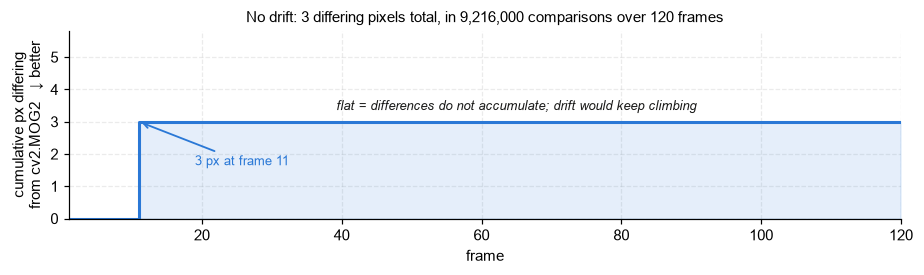

**▸ The line jumps once and then stays flat: differences do not accumulate — the implementation does not drift away from OpenCV.**

In [11]:
from gmm_mask import GMM_Mask_Numba
from settings import (MOG2_HISTORY, MOG2_VAR_THRESHOLD, MOG2_N_COMPONENTS,
                      MOG2_BACKGROUND_RATIO)

if HAS_DATA:
    ours = None
    cvm = cv2.createBackgroundSubtractorMOG2(history=int(MOG2_HISTORY),
            varThreshold=float(MOG2_VAR_THRESHOLD), detectShadows=False)
    cvm.setNMixtures(int(MOG2_N_COMPONENTS)); cvm.setBackgroundRatio(float(MOG2_BACKGROUND_RATIO))
    per_frame = []
    for i in range(1, 121):
        bgr = cv2.imread(f"{HIGHWAY}/input/in{i:06d}.jpg")
        if ours is None: ours = GMM_Mask_Numba(*bgr.shape[:2])
        m, _, _ = ours.apply(np.ascontiguousarray(bgr, np.float32))
        per_frame.append(int((np.asarray(m) != cvm.apply(bgr)).sum()))

    px = 120 * bgr.shape[0] * bgr.shape[1]
    cum = np.cumsum(per_frame)
    fig, ax = plt.subplots(figsize=(8.5, 2.6))
    ax.step(range(1, 121), cum, where="post", color=C["v0"], lw=2)
    ax.fill_between(range(1, 121), cum, step="post", color=C["v0"], alpha=.12)
    first = next(f for f, n in enumerate(per_frame, 1) if n)
    ax.annotate(f"{per_frame[first-1]} px at frame {first}", xy=(first, cum[first-1]),
                xytext=(first + 8, cum[first-1] * .55), fontsize=8.5, color=C["v0"],
                arrowprops=dict(arrowstyle="->", color=C["v0"], lw=1.2))
    ax.text(65, cum[-1] * 1.12, "flat = differences do not accumulate; drift would keep climbing",
            fontsize=8.5, style="italic", color=C["ink"], ha="center")
    ax.set_xlim(1, 120); ax.set_ylim(0, cum[-1] * 1.6 + 1)
    ax.set_xlabel("frame")
    ax.set_ylabel("cumulative px differing\nfrom cv2.MOG2   ↓ better")
    ax.set_title(f"No drift: {cum[-1]} differing pixels total, in {px:,} comparisons over 120 frames",
                 fontsize=10)
    plt.tight_layout(); plt.show()
    take("The line jumps once and then stays flat: differences do not accumulate — "
         "the implementation does not drift away from OpenCV.")


### 3.3 · Masks against the labels

Three scored frames first, then one fixed frame side by side with OpenCV.

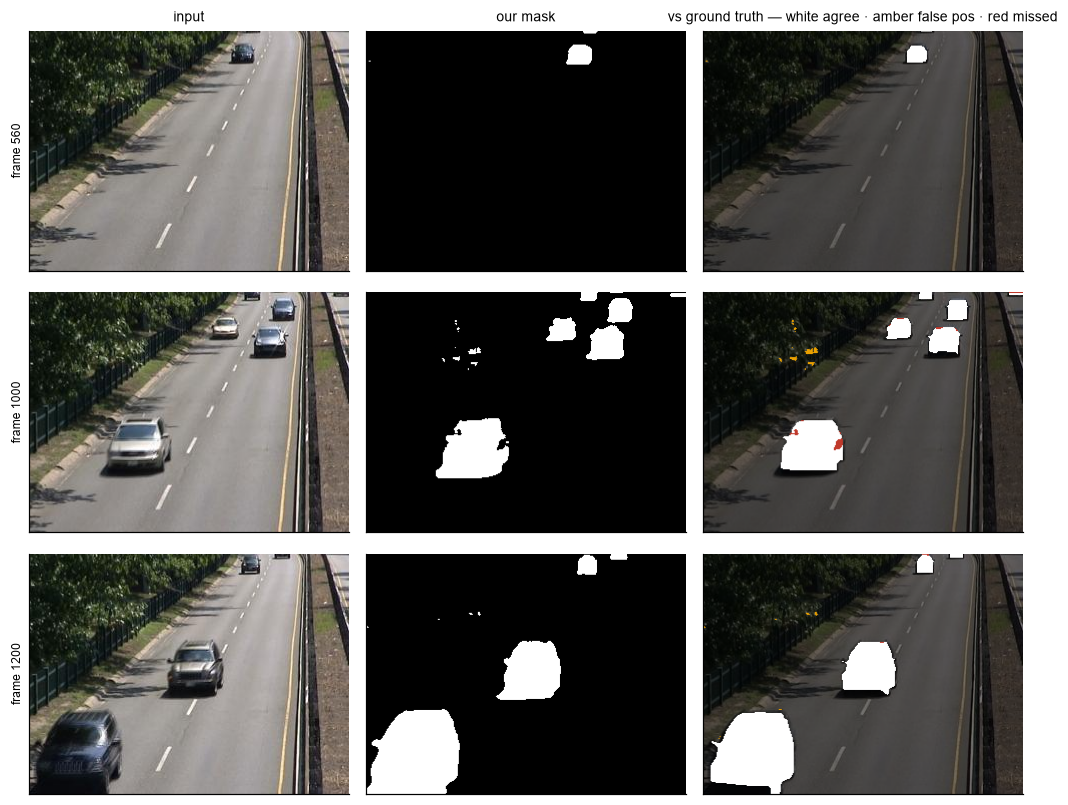

**▸ Errors sit on object boundaries and in shadow, not on whole vehicles.**

In [12]:
from utils.post_processing import refine_mask, fill_holes, threshold_bg_prob

if HAS_DATA:
    m = GMM_Mask_Numba(240, 320)
    keep, want = {}, [560, 1000, 1200]
    for i in range(1, max(want) + 1):
        bgr = cv2.imread(f"{HIGHWAY}/input/in{i:06d}.jpg")
        mask, bg_prob, _ = m.apply(cv2.cvtColor(bgr, cv2.COLOR_BGR2YCrCb))
        if i in want:
            keep[i] = (bgr.copy(),
                       refine_mask(np.asarray(mask), bg_prob=np.asarray(bg_prob)),
                       cv2.imread(f"{HIGHWAY}/groundtruth/gt{i:06d}.png", 0))

    fig, axes = plt.subplots(len(want), 3, figsize=(9.5, 2.5 * len(want)))
    for row, i in zip(axes, want):
        bgr, ours_m, gt = keep[i]
        valid = (gt == 255) | (gt == 0)
        ok = (ours_m == 255) & (gt == 255)
        fp = (ours_m == 255) & (gt == 0)
        fn = (ours_m == 0) & (gt == 255)
        overlay = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB).astype(float) * .45
        overlay[ok] = [255, 255, 255]           # agreement
        overlay[fp] = [235, 161, 0]             # we say fg, label says bg
        overlay[fn] = [192, 57, 43]             # we miss it
        row[0].imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)); row[0].set_ylabel(f"frame {i}", fontsize=8)
        row[1].imshow(ours_m, cmap="gray")
        row[2].imshow(overlay.astype(np.uint8))
        for a in row: a.set_xticks([]); a.set_yticks([])
    axes[0][0].set_title("input", fontsize=9)
    axes[0][1].set_title("our mask", fontsize=9)
    axes[0][2].set_title("vs ground truth — white agree · amber false pos · red missed", fontsize=9)
    plt.tight_layout(); plt.show()
    take("Errors sit on object boundaries and in shadow, not on whole vehicles.")

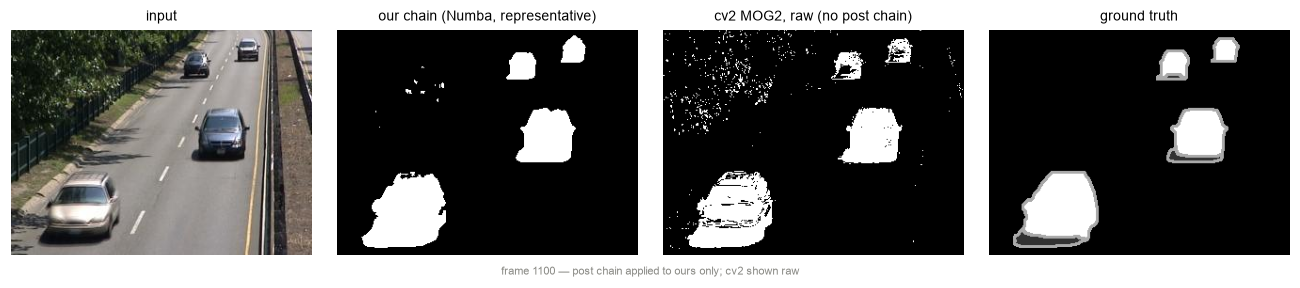

**▸ Numba stands in for all five implementations here: synthetic parity covers them, and the recorded real-frame parity for CUDA v1/v2 differs at 2 proven float-boundary pixels.**

In [13]:
# One fixed frame, judged three ways: our shipping chain, OpenCV's MOG2, the label.
# Fresh models, warmed together from frame 1 — equal model age, each fed its own
# documented input (ours YCrCb, cv2 BGR); the post chain is applied to ours only.
if HAS_DATA:
    F = 1100
    ours2 = GMM_Mask_Numba(240, 320)
    cvm2 = cv2.createBackgroundSubtractorMOG2(history=int(MOG2_HISTORY),
            varThreshold=float(MOG2_VAR_THRESHOLD), detectShadows=False)
    cvm2.setNMixtures(int(MOG2_N_COMPONENTS)); cvm2.setBackgroundRatio(float(MOG2_BACKGROUND_RATIO))
    for i in range(1, F + 1):
        bgr = cv2.imread(f"{HIGHWAY}/input/in{i:06d}.jpg")
        mask, bg_prob, _ = ours2.apply(cv2.cvtColor(bgr, cv2.COLOR_BGR2YCrCb))
        cv_mask = cvm2.apply(bgr)
    ours_m = refine_mask(np.asarray(mask), bg_prob=np.asarray(bg_prob))
    gt = cv2.imread(f"{HIGHWAY}/groundtruth/gt{F:06d}.png", 0)
    panels = [("input", cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)),
              ("our chain (Numba, representative)", ours_m),
              ("cv2 MOG2, raw (no post chain)", cv_mask),
              ("ground truth", gt)]
    fig, ax = plt.subplots(1, 4, figsize=(12, 2.6))
    for a, (t, im) in zip(ax, panels):
        a.imshow(im, cmap=None if im.ndim == 3 else "gray")
        a.set_title(t, fontsize=9); a.axis("off")
    fig.suptitle(f"frame {F} — post chain applied to ours only; cv2 shown raw", fontsize=7.5, y=.02, color=C["muted"])
    plt.tight_layout(); plt.show()
    take("Numba stands in for all five implementations here: synthetic parity covers them, "
         "and the recorded real-frame parity for CUDA v1/v2 differs at 2 proven float-boundary pixels.")

### 3.4 · Throughput on synthetic frames

The recorded T4 ladder — the numbers every prediction in §4.1 was tested against.

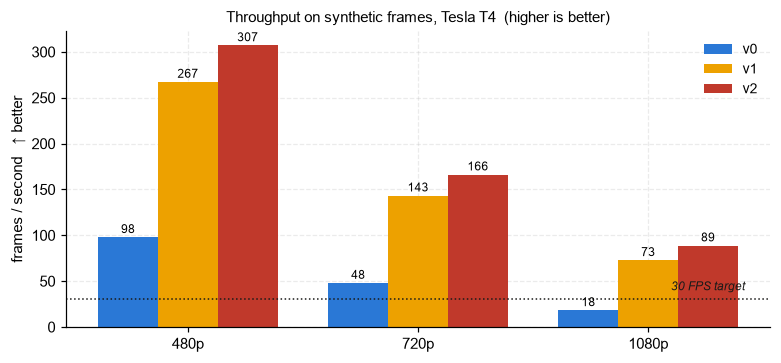

**▸ 88.8 FPS at 1080p — 4.89× the v0 baseline, and 2.9× the 30 FPS target. The proposal's other target, >20× over sequential Python, closes at 887× at 480p (RESULTS-T4 §3: sequential 3 034.62 ms/frame).**

In [14]:
x = np.arange(3); w = .26
fig, ax = plt.subplots(figsize=(7.2, 3.4))
for i, v in enumerate(("v0", "v1", "v2")):
    b = ax.bar(x + (i-1)*w, T4[v]["fps"], w, label=v, color=C[v])
    ax.bar_label(b, fmt="%.0f", fontsize=8, padding=1)
ax.axhline(30, color=C["ink"], lw=1, ls=":")
ax.text(2.42, 40, "30 FPS target", ha="right", fontsize=8, style="italic", color=C["ink"])
ax.set_xticks(x); ax.set_xticklabels(SIZES)
ax.set_ylabel("frames / second   ↑ better")
ax.set_title("Throughput on synthetic frames, Tesla T4  (higher is better)", fontsize=10)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

sp = T4["v0"]["ms"][2] / T4["v2"]["ms"][2]
take(f"88.8 FPS at 1080p — {sp:.2f}× the v0 baseline, and 2.9× the 30 FPS target. "
     "The proposal's other target, >20× over sequential Python, closes at 887× "
     "at 480p (RESULTS-T4 §3: sequential 3 034.62 ms/frame).")

### 3.5 · Throughput on real footage

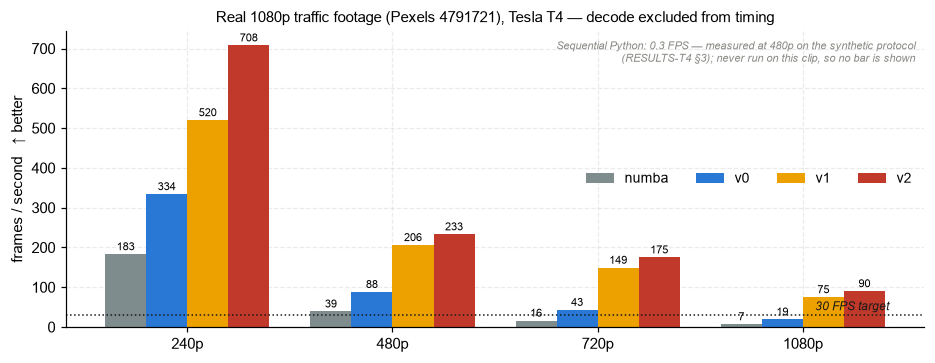

**▸ On real footage v2 holds 90 FPS at 1080p — 4.8x v0 and 13x the CPU. The synthetic-frame story holds on real frames (decode itself not timed).**

In [15]:
# The referee question about every synthetic-frame table: does the speedup
# survive a real decoder and real footage? Same 1080p clip at four sizes.
RF = REALFOOTAGE_T4
xs = np.arange(len(RF["tiers"])); w = .2
fig, ax = plt.subplots(figsize=(8.6, 3.4))
for i, (v, col) in enumerate((("numba", "#7f8c8d"), ("v0", C["v0"]),
                              ("v1", C["v1"]), ("v2", C["v2"]))):
    b = ax.bar(xs + (i - 1.5) * w, RF[v]["fps"], w, label=v, color=col)
    ax.bar_label(b, fmt="%.0f", fontsize=7.5, padding=1)
ax.axhline(30, color=C["ink"], lw=1, ls=":")
ax.text(3.42, 42, "30 FPS target", ha="right", fontsize=8, style="italic", color=C["ink"])
ax.set_xticks(xs); ax.set_xticklabels(RF["tiers"])
ax.set_ylabel("frames / second   ↑ better")
ax.set_title("Real 1080p traffic footage (Pexels 4791721), Tesla T4 — decode excluded from timing", fontsize=10)
ax.legend(frameon=False, fontsize=9, ncols=4)
ax.text(.99, .97, "Sequential Python: 0.3 FPS — measured at 480p on the synthetic protocol\n(RESULTS-T4 §3); never run on this clip, so no bar is shown",
        transform=ax.transAxes, ha="right", va="top", fontsize=7.5, style="italic", color=C["muted"])
plt.tight_layout(); plt.show()

take("On real footage v2 holds 90 FPS at 1080p — 4.8x v0 and 13x the CPU. "
     "The synthetic-frame story holds on real frames (decode itself not timed).")

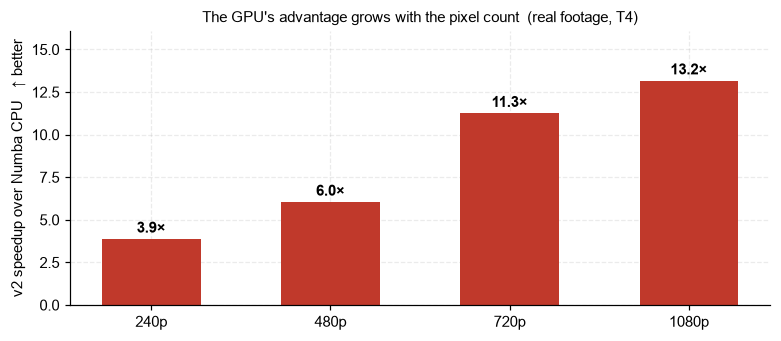

**▸ 13.2× over the compiled CPU at 1080p — and 887× over sequential Python at 480p, but Numba CPU is the honest baseline (RESULTS-T4 §3).**

In [16]:
# What did the GPU actually buy? v2 vs the compiled CPU baseline, same real
# footage, same protocol — computed live from the recorded table above.
RF = REALFOOTAGE_T4
sp = [n / v for n, v in zip(RF["numba"]["ms"], RF["v2"]["ms"])]
fig, ax = plt.subplots(figsize=(7.2, 3.2))
b = ax.bar(RF["tiers"], sp, .55, color=C["v2"])
ax.bar_label(b, labels=[f"{s:.1f}×" for s in sp], fontsize=10, fontweight="bold", padding=2)
ax.set_ylabel("v2 speedup over Numba CPU   ↑ better")
ax.set_title("The GPU's advantage grows with the pixel count  (real footage, T4)", fontsize=10)
ax.set_ylim(0, max(sp) * 1.22)
plt.tight_layout(); plt.show()

take(f"{sp[-1]:.1f}× over the compiled CPU at 1080p — and 887× over sequential "
     "Python at 480p, but Numba CPU is the honest baseline (RESULTS-T4 §3).")

### 3.6 · Where the time goes

The chart breaks down every stage in all three versions. Blue drops from v0→v1 when ingest moves to the device, and grey drops from v1→v2 with tiling. **Red stays flat:** it is the flood fill discussed in §2.5.

The ingest drop v0→v1 (23.21 → 1.65 ms at 1080p) is mostly host work *deleted* — the conversion kernel added on the device costs just 0.184 ms.

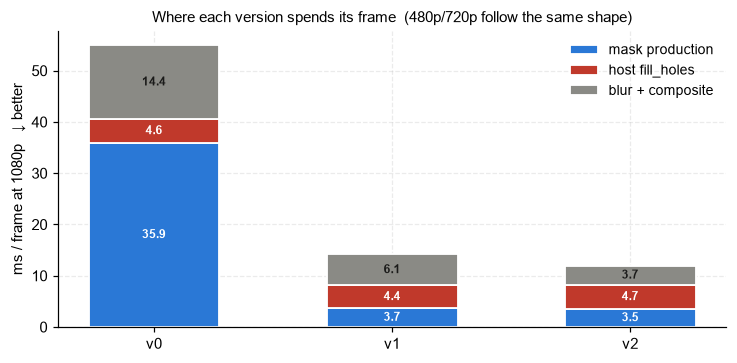

**▸ At 1080p the largest single stage of v2 is now the host flood fill — 39.7%. The next win is CUDA streams, not a faster kernel.**

In [17]:
stage_cols = {"mask production": C["v0"], "host fill_holes": C["v2"],
              "blur + composite": C["muted"]}
fig, ax = plt.subplots(figsize=(6.8, 3.4))
bottom = np.zeros(3)
for stage, col in stage_cols.items():
    vals = [PERSTAGE[v][stage][2] for v in ("v0", "v1", "v2")]   # [2] = 1080p
    ax.bar(np.arange(3), vals, .55, bottom=bottom, color=col, label=stage,
           edgecolor="white", linewidth=1.2)
    for xi, (v, b0) in enumerate(zip(vals, bottom)):
        ax.text(xi, b0 + v/2, f"{v:.1f}", ha="center", va="center", fontsize=8,
                fontweight="bold", color="white" if col != C["muted"] else C["ink"])
    bottom += np.array(vals)
ax.set_xticks(np.arange(3)); ax.set_xticklabels(["v0", "v1", "v2"])
ax.set_ylabel("ms / frame at 1080p   ↓ better")
ax.set_title("Where each version spends its frame  (480p/720p follow the same shape)", fontsize=10)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

tot = sum(v[2] for v in PERSTAGE["v2"].values())
take(f"At 1080p the largest single stage of v2 is now the host flood fill — "
     f"{PERSTAGE['v2']['host fill_holes'][2]/tot:.1%}. The next win is CUDA streams, not a faster kernel.")

### 3.7 · End-to-end result

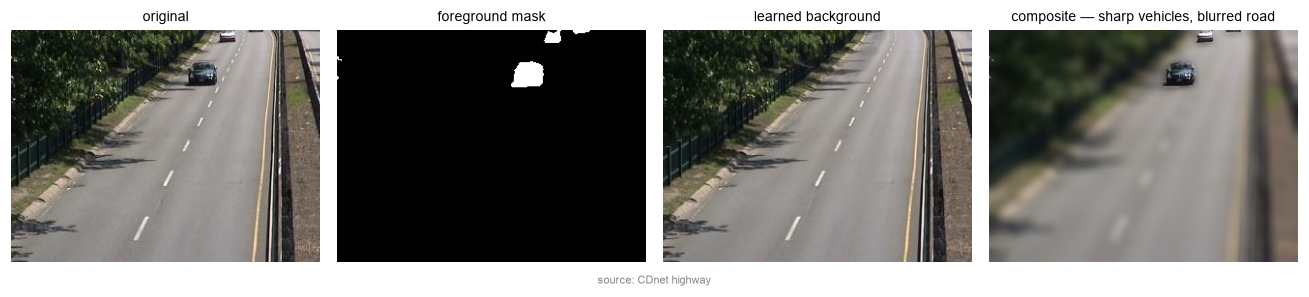

In [18]:
from utils.post_processing import background_blur
from settings import BLUR_KSIZE, BLUR_SIGMA

frames, src = load_sequence(600)
h, w = frames[0].shape[:2]
m = GMM_Mask_Numba(h, w)
for bgr in frames:
    mask, bg_prob, _ = m.apply(cv2.cvtColor(bgr, cv2.COLOR_BGR2YCrCb))
refined = refine_mask(np.asarray(mask), bg_prob=np.asarray(bg_prob))
out = background_blur(bgr, refined, BLUR_KSIZE, BLUR_SIGMA)
bg  = cv2.cvtColor(m.background_image(), cv2.COLOR_YCrCb2RGB)  # model was fed YCrCb

fig, ax = plt.subplots(1, 4, figsize=(12, 2.7))
for a, (t, im) in zip(ax, [("original", cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)),
                           ("foreground mask", refined),
                           ("learned background", bg),
                           ("composite — sharp vehicles, blurred road",
                            cv2.cvtColor(out, cv2.COLOR_BGR2RGB))]):
    a.imshow(im, cmap=None if im.ndim == 3 else "gray")
    a.set_title(t, fontsize=9); a.axis("off")
fig.suptitle(f"source: {src}", fontsize=7.5, y=.02, color=C["muted"])
plt.tight_layout(); plt.show()

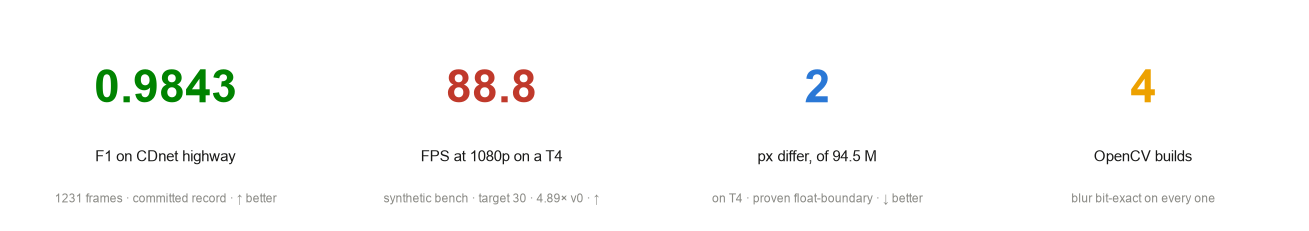

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(12, 2.2))
tiles = [("0.9843", "F1 on CDnet highway", "1231 frames · committed record · ↑ better", C["good"]),
         ("88.8", "FPS at 1080p on a T4", "synthetic bench · target 30 · 4.89× v0 · ↑",   C["v2"]),
         ("2", "px differ, of 94.5 M", "on T4 · proven float-boundary · ↓ better", C["v0"]),
         ("4", "OpenCV builds", "blur bit-exact on every one",                 C["v1"])]
for a, (big, label, sub, col) in zip(axes, tiles):
    a.axis("off")
    a.text(.5, .62, big, ha="center", va="center", fontsize=30, fontweight="bold", color=col)
    a.text(.5, .30, label, ha="center", va="center", fontsize=10, color=C["ink"])
    a.text(.5, .10, sub, ha="center", va="center", fontsize=8, color=C["muted"])
plt.tight_layout(); plt.show()

## 4 · Discussion

### 4.1 · Our predictions: five of six were wrong

All six, exactly as recorded in `RESULTS-T4.md` §8 before the benchmark ran:

| Prediction (written first) | Predicted | Measured | Verdict |
|---|---|---|---|
| Host blur + composite @1080p | 4–8 ms | 13.7 ms | ✗ 2–3× worse |
| GPU blur kernels @1080p | 0.2–0.4 ms | 1.55 ms | ✗ ~4–8× costlier |
| Ingest + blur saving @1080p | 4–8 ms | ~34 ms | ✗ 4–8× larger |
| Bus traffic reduction | −38.5% | −52.9% | ✗ larger |
| Tiled vs naive blur | *"probably close to naive"* | **2.36× faster** | ✗ — better than predicted |
| Bottleneck after the change | host `fill_holes` | confirmed, 39.7% @1080p | ✓ the one that held |

**Three misses underestimated the host and the bus. One underestimated what a GPU kernel costs. One went the other way: tiling did better.**

The tiling result surprised us most. We expected the L2 layout to provide enough reuse, but shared tiles deliver **2.36×** at three resolutions under two measurement protocols. Writing down the prediction first made the mismatch clear and worth explaining.

### 4.2 · What we learned

- **The host was the bottleneck, not the arithmetic.** Removing host work produced 76 % of the ingest saving.
- **Q8 fixed-point arithmetic (integers with a fixed scale) made the device blur bit-exact.** This was a correctness win.
- **The separately validated integer YCrCb conversion enabled the 3 B/px upload.** This was a data-transfer win.
- **Some stages should stay on the CPU.** Flood fill costs 593 dependent passes (`bench_fill.py`); GrabCut added +2.1 F1 at ~141× the cost and was removed (measured at `aa4dfb7`, not reproducible from this checkout).

## 5 · Conclusion

One algorithm, five implementations, every claim tested. Quality **F1 0.9843** on CDnet highway; speed **88.8 FPS** synthetic and **90 FPS** on real footage at 1080p — both proposal targets closed (30 FPS; >20× over sequential Python, at 887×). GPU-vs-CPU agreement is bounded to **2 proven float-boundary pixels in 94.5 M**. The speedup came from moving data less, not from computing faster.

### 5.1 · Limitations
- CDnet hosts are offline, so we depend on our HuggingFace mirror.
- Floating-point results differ across compilers by design; we bound it: 2 px of 94.5 M, both proven boundary cases on the T4.
- Timings can vary on shared Colab GPUs.
- CUDASIM (CUDA's CPU-based simulator) checks logic, but real GPU behavior still needs hardware tests.

### 5.2 · Future work

- **Pinned (page-locked) buffers + CUDA streams (ladder L4):** overlap the host flood fill with the next frame's ingest — fill is now the largest single stage. Identified by the profile, **not a claimed result**.
- **Fused separable blur:** legal (the blur has no side effects, so halo recompute is safe) but unmeasured — both blur kernels are ≈1.55 ms of 11.07 ms at 1080p, so the ceiling is small.
- A labelled 1080p dataset would let quality be scored where throughput is measured.

*Zivkovic 2004 · Stauffer & Grimson 1999 · Wang et al., CDnet 2014 · OpenCV `bgfg_gaussmix2.cpp`, `smooth.simd.hpp` · Measurements: Colab T4, `RESULTS-T4.md` · quality record: `benchmarks/records/eval_highway_full.txt`*